# Analisis de alquileres scrapeados

Este notebook analiza el archivo generado por el scraper: `data/processed/infocasas_1_dormitorio_detalle.csv`.

El objetivo es revisar todos los tipos de alquiler disponibles en la muestra, no solo apartamentos. Para eso usamos `tipo_propiedad`, `barrio`, `moneda`, `monto`, `gastos_comunes` y `metros_cuadrados`.

Para comparar oportunidades entre monedas, este analisis convierte dolares a pesos con `TIPO_CAMBIO_USD_UYU = 40`.


Los resultados del analisis se muestran dentro del notebook. No se exportan CSVs ni imagenes derivados para que el outcome sea unico y reproducible desde este archivo.


## 1. Importar librerias y ubicar el proyecto

Esta celda busca la raiz del proyecto para que el notebook funcione aunque se abra desde `notebooks/` o desde la carpeta raiz.


In [ ]:
from datetime import date
from pathlib import Path
import os
import re
import unicodedata

import pandas as pd

def encontrar_raiz_proyecto() -> Path:
    actual = Path.cwd().resolve()
    for ruta in [actual, *actual.parents]:
        if (ruta / 'data' / 'processed' / 'infocasas_1_dormitorio_detalle.csv').exists():
            return ruta
    raise FileNotFoundError('No se encontro data/processed/infocasas_1_dormitorio_detalle.csv')

ROOT_DIR = encontrar_raiz_proyecto()
DATA_PATH = ROOT_DIR / 'data' / 'processed' / 'infocasas_1_dormitorio_detalle.csv'
FECHA_ANALISIS = date.today().isoformat()
TIPO_CAMBIO_USD_UYU = 40

MPLCONFIG_DIR = ROOT_DIR / 'data' / 'processed' / 'analysis' / 'matplotlib_config'
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIG_DIR))

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

ROOT_DIR


WindowsPath('C:/Users/Administrador/Documents/GitHub/Scrapper-alquileres')

## 2. Cargar el dataset crudo


In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Filas: {len(df_raw)}')
print(f'Columnas: {len(df_raw.columns)}')
df_raw.head()


Filas: 977
Columnas: 13


,url,titulo,precio,moneda,monto,barrio,dormitorios,banios,metros_cuadrados,gastos_comunes,tipo_propiedad,referencia,descripcion
0,https://www.infocasas.com.uy/alquiler-de-apart...,"Alquiler de Apartamento en Cordón Sur 10283, 1...",$ 30.000,$,30000.0,Cordón,1.0,1.0,48.0,NaN,Apartamento,WA5494,Alquiler de Apartamento 1 Dormitorios en Cordó...
1,https://www.infocasas.com.uy/alquiler-de-apart...,Alquiler de apartamento de 1 dormitorio en Cor...,$ 30.000,$,30000.0,Cordón,1.0,1.0,0.0,$ 3.500,Apartamento,ZCEC70,"Apartamento a estrenar en zona Cordón Sur, Jua..."
2,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler Apartamento 1 Dormitorio en Pocitos N...,$ 33.900,$,33900.0,Pocitos Nuevo,1.0,1.0,43.0,$ 9.900,Apartamento,OE9C4E,Alquiler de apartamento amoblado de 1 dormitor...
3,https://www.infocasas.com.uy/noi-artes-103-alq...,Noi Artes (103) - Alquiler Apartamento 1 Dormi...,$ 30.500,$,30500.0,Centro,1.0,1.0,43.0,$ 4.500,Apartamento,T6A0B9,Alquiler Apartamento 1 Dormitorio&nbsp; con Pa...
4,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler apartamento de 1 domitorio en Centro.,$ 21.000,$,21000.0,Centro,1.0,1.0,49.0,NaN,Apartamento,EB99EC,Viví en una ubicación estratégica de Montevide...


## 3. Limpieza basica

Normalizamos columnas numericas, convertimos gastos comunes a numero y calculamos costo mensual total. Tambien dejamos `precio_m2` como metrica derivada.


In [ ]:
def limpiar_monto_gastos(valor):
    if pd.isna(valor):
        return 0.0
    texto = str(valor).strip()
    if not texto:
        return 0.0
    numero = re.sub(r'[^0-9]', '', texto)
    monto = float(numero) if numero else 0.0
    return monto * TIPO_CAMBIO_USD_UYU if 'U$S' in texto.upper() else monto

def gasto_informado(valor):
    return not pd.isna(valor) and bool(str(valor).strip())

def convertir_alquiler_a_pesos(row):
    if row['moneda'] == 'U$S':
        return row['monto'] * TIPO_CAMBIO_USD_UYU
    if row['moneda'] == '$':
        return row['monto']
    return pd.NA

df = df_raw.copy()

for columna in ['monto', 'dormitorios', 'banios', 'metros_cuadrados']:
    df[columna] = pd.to_numeric(df[columna], errors='coerce')

if 'fecha_scraping' not in df.columns:
    df['fecha_scraping'] = pd.NA
df['fecha_analisis'] = FECHA_ANALISIS

df['gastos_comunes_informados'] = df['gastos_comunes'].apply(gasto_informado)
df['gastos_comunes_monto'] = df['gastos_comunes'].apply(limpiar_monto_gastos)
df['alquiler_pesos'] = df.apply(convertir_alquiler_a_pesos, axis=1)
df['gastos_comunes_pesos'] = df['gastos_comunes_monto']
df['costo_mensual_total_pesos'] = df['alquiler_pesos'] + df['gastos_comunes_pesos']
df['costo_mensual_total'] = df['costo_mensual_total_pesos']
df['gastos_sobre_alquiler_pct'] = df['gastos_comunes_pesos'] / df['alquiler_pesos']
df.loc[df['metros_cuadrados'] <= 0, 'metros_cuadrados'] = pd.NA
df['precio_m2'] = df['monto'] / df['metros_cuadrados']
df['precio_m2_pesos'] = df['alquiler_pesos'] / df['metros_cuadrados']
df['costo_total_m2_pesos'] = df['costo_mensual_total_pesos'] / df['metros_cuadrados']

df.head()


,url,titulo,precio,moneda,monto,barrio,dormitorios,banios,metros_cuadrados,gastos_comunes,...,gastos_comunes_informados,gastos_comunes_monto,alquiler_pesos,gastos_comunes_pesos,costo_mensual_total_pesos,costo_mensual_total,gastos_sobre_alquiler_pct,precio_m2,precio_m2_pesos,costo_total_m2_pesos
0,https://www.infocasas.com.uy/alquiler-de-apart...,"Alquiler de Apartamento en Cordón Sur 10283, 1...",$ 30.000,$,30000.0,Cordón,1.0,1.0,48.0,NaN,...,False,0.0,30000.0,0.0,30000.0,30000.0,0.0,625.000000,625.0,625.0
1,https://www.infocasas.com.uy/alquiler-de-apart...,Alquiler de apartamento de 1 dormitorio en Cor...,$ 30.000,$,30000.0,Cordón,1.0,1.0,NaN,$ 3.500,...,True,3500.0,30000.0,3500.0,33500.0,33500.0,0.116667,NaN,NaN,NaN
2,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler Apartamento 1 Dormitorio en Pocitos N...,$ 33.900,$,33900.0,Pocitos Nuevo,1.0,1.0,43.0,$ 9.900,...,True,9900.0,33900.0,9900.0,43800.0,43800.0,0.292035,788.372093,788.372093,1018.604651
3,https://www.infocasas.com.uy/noi-artes-103-alq...,Noi Artes (103) - Alquiler Apartamento 1 Dormi...,$ 30.500,$,30500.0,Centro,1.0,1.0,43.0,$ 4.500,...,True,4500.0,30500.0,4500.0,35000.0,35000.0,0.147541,709.302326,709.302326,813.953488
4,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler apartamento de 1 domitorio en Centro.,$ 21.000,$,21000.0,Centro,1.0,1.0,49.0,NaN,...,False,0.0,21000.0,0.0,21000.0,21000.0,0.0,428.571429,428.571429,428.571429


## 4. Calidad de datos


In [ ]:
faltantes = df.isna().sum().rename_axis('columna').reset_index(name='faltantes')
faltantes


,columna,faltantes
0,url,0
1,titulo,0
2,precio,1
3,moneda,1
4,monto,1
5,barrio,1
6,dormitorios,1
7,banios,1
8,metros_cuadrados,116
9,gastos_comunes,300


## 5. Composicion de la muestra

Primero miramos que tipos de propiedad y barrios aparecen. Esto define que comparaciones tienen sentido.


In [ ]:
conteo_tipo = df['tipo_propiedad'].value_counts(dropna=False).rename_axis('tipo_propiedad').reset_index(name='cantidad')
conteo_barrio = df['barrio'].value_counts(dropna=False).rename_axis('barrio').reset_index(name='cantidad')


display(conteo_tipo)
display(conteo_barrio.head(15))


,tipo_propiedad,cantidad
0,Apartamento,863
1,Casa,61
2,Local Comercial,16
3,Local industrial o galpón,13
4,Oficina,13
5,Garaje o Cochera,4
6,Terreno,3
7,Chacra o Campo,2
8,Edificio,1
9,NaN,1


,barrio,cantidad
0,Pocitos,93
1,Cordón,92
2,Centro,67
3,La Blanqueada,57
4,Punta Carretas,56
5,Tres Cruces,55
6,Malvín,45
7,Buceo,38
8,Ciudad Vieja,29
9,Península,21


## 6. Revision de moneda

No conviene comparar precios en pesos y dolares como si fueran la misma unidad. Primero analizamos por moneda.


In [ ]:
df['moneda'].value_counts(dropna=False)


moneda
$      776
U$S    200
NaN      1
Name: count, dtype: int64

## 7. Precio por tipo de propiedad


In [ ]:
precio_tipo = (
    df.groupby(['moneda', 'tipo_propiedad'], dropna=False)['monto']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)
precio_tipo


,moneda,tipo_propiedad,count,mean,median,min,max
0,$,Apartamento,693,28063.493506,28000.0,10000.0,78000.0
1,$,Casa,55,22734.545455,21000.0,12800.0,40000.0
2,$,Chacra o Campo,2,64000.000000,64000.0,8000.0,120000.0
3,$,Edificio,1,11000.000000,11000.0,11000.0,11000.0
4,$,Garaje o Cochera,3,4000.000000,4000.0,3500.0,4500.0
5,$,Local Comercial,10,58800.000000,46000.0,12000.0,120000.0
6,$,Local industrial o galpón,3,101000.000000,120000.0,8000.0,175000.0
7,$,Oficina,6,22650.000000,23500.0,15000.0,27900.0
8,$,Terreno,3,52666.666667,50000.0,48000.0,60000.0
9,U$S,Apartamento,170,2321.888235,1250.0,110.0,48500.0


## 8. Precio por barrio


In [ ]:
precio_barrio = (
    df.groupby(['moneda', 'barrio'], dropna=False)['monto']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values(['moneda', 'median'], na_position='last')
)
precio_barrio


,moneda,barrio,count,mean,median,min,max
97,$,Zona Rural,1,8000.000000,8000.0,8000.0,8000.0
28,$,Florida,1,12000.000000,12000.0,12000.0,12000.0
83,$,Santa Maria del Rivieiro,1,12800.000000,12800.0,12800.0,12800.0
84,$,Santa Monica,1,13000.000000,13000.0,13000.0,13000.0
11,$,Belvedere,3,14666.666667,13500.0,13500.0,17000.0
...,...,...,...,...,...,...,...
113,U$S,Colón,1,9375.000000,9375.0,9375.0,9375.0
126,U$S,Montoya,1,10500.000000,10500.0,10500.0,10500.0
133,U$S,Pinares de Solymar,2,18000.000000,18000.0,18000.0,18000.0
143,U$S,Rincón del Indio,1,48500.000000,48500.0,48500.0,48500.0


## 9. Costo mensual total


In [ ]:
costo_total_barrio = (
    df.groupby(['moneda', 'barrio'], dropna=False)['costo_mensual_total']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values(['moneda', 'median'], na_position='last')
)
costo_total_barrio


,moneda,barrio,count,mean,median,min,max
97,$,Zona Rural,1,8000.0,8000.0,8000.0,8000.0
28,$,Florida,1,12000.0,12000.0,12000.0,12000.0
83,$,Santa Maria del Rivieiro,1,12800.0,12800.0,12800.0,12800.0
84,$,Santa Monica,1,13000.0,13000.0,13000.0,13000.0
11,$,Belvedere,3,14666.666667,13500.0,13500.0,17000.0
...,...,...,...,...,...,...,...
113,U$S,Colón,1,375000.0,375000.0,375000.0,375000.0
126,U$S,Montoya,1,420000.0,420000.0,420000.0,420000.0
133,U$S,Pinares de Solymar,2,720000.0,720000.0,720000.0,720000.0
143,U$S,Rincón del Indio,1,1984720.0,1984720.0,1984720.0,1984720.0


## 10. Precio por metro cuadrado


In [ ]:
precio_m2_barrio = (
    df.dropna(subset=['precio_m2'])
    .groupby(['moneda', 'barrio'], dropna=False)['precio_m2']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values(['moneda', 'median'], na_position='last')
)
precio_m2_barrio


,moneda,barrio,count,mean,median,min,max
41,$,Las vegas,1,60.000000,60.000000,60.000000,60.000000
92,$,Zona Rural,1,123.076923,123.076923,123.076923,123.076923
64,$,Peñarol,1,160.000000,160.000000,160.000000,160.000000
22,$,Colón,1,184.615385,184.615385,184.615385,184.615385
46,$,Maroñas,4,254.605263,221.710526,75.000000,500.000000
...,...,...,...,...,...,...,...
100,U$S,Cantegril,2,96.607143,96.607143,95.000000,98.214286
111,U$S,La Barra,2,98.125000,98.125000,21.250000,175.000000
115,U$S,Laguna del Diario,1,144.444444,144.444444,144.444444,144.444444
132,U$S,Rincón del Indio,1,283.625731,283.625731,283.625731,283.625731


## 11. Facilidades detectadas

Extraemos senales simples desde titulo y descripcion. No reemplaza una revision manual, pero ayuda a priorizar avisos con mejor valor agregado.


In [ ]:
def normalizar_texto(valor):
    if pd.isna(valor):
        return ''
    texto = unicodedata.normalize('NFKD', str(valor))
    texto = ''.join(char for char in texto if not unicodedata.combining(char))
    return texto.lower()

df['texto_busqueda'] = (df['titulo'].fillna('') + ' ' + df['descripcion'].fillna('')).apply(normalizar_texto)

facilidades = {
    'tiene_garaje': r'\b(garaje|garage|cochera|estacionamiento)\b',
    'acepta_mascotas': r'(acepta mascota|permite mascota|pet friendly|mascotas)',
    'amoblado': r'\b(amoblado|amueblado|equipado|muebles)\b',
    'a_estrenar': r'a estrenar|nuevo',
    'tiene_terraza': r'\b(terraza|balcon)\b',
    'tiene_patio': r'\bpatio\b',
    'tiene_parrillero': r'\b(parrillero|barbacoa|parrilla)\b',
    'tiene_laundry': r'\b(laundry|lavadero|lavanderia)\b',
    'tiene_gimnasio': r'\b(gimnasio|gym)\b',
    'tiene_cowork': r'\b(cowork|co-work|coworking|business center)\b',
    'tiene_seguridad': r'\b(seguridad|porteria|vigilancia|cctv|portero)\b',
    'tiene_aire_acondicionado': r'aire acondicionado|\baa\b|split',
    'garantia_flexible': r'anda|contaduria|cgn|porto|sura|mapfre|aseguradora|deposito',
}

for columna, patron in facilidades.items():
    df[columna] = df['texto_busqueda'].str.contains(patron, regex=True, na=False)

df['cantidad_facilidades'] = df[list(facilidades)].sum(axis=1)

resumen_facilidades = (
    df[list(facilidades)]
    .mean()
    .sort_values(ascending=False)
    .rename_axis('facilidad')
    .reset_index(name='porcentaje_publicaciones')
)
resumen_facilidades


C:\Users\Administrador\AppData\Local\Temp\ipykernel_23364\3617011329.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[columna] = df['texto_busqueda'].str.contains(patron, regex=True, na=False)


,facilidad,porcentaje_publicaciones
0,tiene_terraza,0.517912
1,garantia_flexible,0.498465
2,tiene_garaje,0.390993
3,tiene_seguridad,0.371546
4,tiene_parrillero,0.336745
5,tiene_aire_acondicionado,0.318321
6,amoblado,0.314227
7,tiene_laundry,0.289662
8,a_estrenar,0.283521
9,tiene_gimnasio,0.211873


## 12. Entendimiento de gastos

Miramos gastos comunes en pesos, su peso relativo sobre el alquiler y casos donde no fueron informados.


In [ ]:
gastos_por_barrio = (
    df[df['moneda'].isin(['$', 'U$S'])]
    .groupby('barrio', dropna=False)
    .agg(
        publicaciones=('url', 'count'),
        gastos_medianos=('gastos_comunes_pesos', 'median'),
        gastos_promedio=('gastos_comunes_pesos', 'mean'),
        pct_gastos_no_informados=('gastos_comunes_informados', lambda s: 1 - s.mean()),
        gastos_sobre_alquiler_mediano=('gastos_sobre_alquiler_pct', 'median'),
    )
    .reset_index()
    .sort_values('gastos_sobre_alquiler_mediano', ascending=False, na_position='last')
)
gastos_por_barrio.head(20)


,barrio,publicaciones,gastos_medianos,gastos_promedio,pct_gastos_no_informados,gastos_sobre_alquiler_mediano
27,Colonia del Sacramento,1,9500.0,9500.000000,0.000000,0.287879
12,Bella Vista,3,6399.0,4266.000000,0.333333,0.266625
112,Villa Biarritz,4,8050.0,8000.000000,0.000000,0.253486
4,Av De Las Americas,1,12200.0,12200.000000,0.000000,0.219424
54,Malvín,45,5500.0,5310.600000,0.022222,0.193548
90,Puerto Buceo,17,11000.0,8937.352941,0.058824,0.191176
92,Punta Gorda,7,5900.0,4028.571429,0.285714,0.190323
10,Bañados de Carrasco,1,11900.0,11900.000000,0.000000,0.187107
73,Parque de Miramar,1,7000.0,7000.000000,0.000000,0.184211
85,Pocitos Nuevo,11,6500.0,6189.363636,0.090909,0.184211


In [ ]:
alertas_gastos_altos = (
    df[df['gastos_sobre_alquiler_pct'].notna() & (df['gastos_sobre_alquiler_pct'] >= 0.25)]
    .sort_values('gastos_sobre_alquiler_pct', ascending=False)
    [[
        'barrio', 'tipo_propiedad', 'titulo', 'moneda', 'monto',
        'gastos_comunes', 'alquiler_pesos', 'gastos_comunes_pesos',
        'gastos_sobre_alquiler_pct', 'url'
    ]]
)
alertas_gastos_altos.head(20)


,barrio,tipo_propiedad,titulo,moneda,monto,gastos_comunes,alquiler_pesos,gastos_comunes_pesos,gastos_sobre_alquiler_pct,url
164,Cordón,Apartamento,Alquiler apartamento 1 dormitorio con balcón -...,$,27000.0,$ 49.996,27000.0,49996.0,1.851704,https://www.infocasas.com.uy/alquiler-apartame...
714,Playa Brava,Apartamento,Elegancia Moderna en la Exclusiva Torre Trump ...,U$S,2500.0,U$S 2.800,100000.0,112000.0,1.12,https://www.infocasas.com.uy/elegancia-moderna...
262,Maldonado,Apartamento,"Apartamento 1 Dormitorio, sobre centro comercial",U$S,1200.0,$ 35.513,48000.0,35513.0,0.739854,https://www.infocasas.com.uy/apartamento-1-dor...
692,Ciudad Vieja,Oficina,Alquiler oficina 80m2 Ciudad Vieja opción garaje,$,24000.0,$ 15.149,24000.0,15149.0,0.631208,https://www.infocasas.com.uy/alquiler-oficina-...
544,Aidy Grill,Apartamento,"Departamento en Alquiler Punta del Este, 1 dor...",U$S,920.0,U$S 420,36800.0,16800.0,0.456522,https://www.infocasas.com.uy/departamento-en-a...
355,Centro,Apartamento,Apartamento de 1 dormitorio en el Centro,$,19000.0,$ 8.500,19000.0,8500.0,0.447368,https://www.infocasas.com.uy/apartamento-de-1-...
961,Carrasco,Apartamento,"Apartamento amplio y luminoso de 1 dormitorio,...",U$S,1000.0,$ 17.500,40000.0,17500.0,0.4375,https://www.infocasas.com.uy/apartamento-ampli...
126,Centro,Apartamento,Apartamentos en Centro,$,17000.0,$ 6.750,17000.0,6750.0,0.397059,https://www.infocasas.com.uy/apartamentos-en-c...
370,Ciudad Vieja,Apartamento,Apartamento 1 Dorm | Barrio Sur | Alma Duc by ...,$,33000.0,$ 13.040,33000.0,13040.0,0.395152,https://www.infocasas.com.uy/apartamento-1-dor...
189,Barrio Sur,Apartamento,Alma Duç (301) - Alquiler Apartamento 1 Dormit...,$,33000.0,$ 13.000,33000.0,13000.0,0.393939,https://www.infocasas.com.uy/alma-duc-301-alqu...


## 13. Ranking de buenas oportunidades

El ranking prioriza apartamentos en Montevideo con costo total bajo frente a comparables del mismo barrio y dormitorios. Tambien suma valor por facilidades y penaliza gastos no informados.

Como el dataset no trae una columna de departamento, se filtra Montevideo usando una lista explicita de barrios normalizados.


In [ ]:
from IPython.display import HTML, display

MONTEVIDEO_BARRIOS = {
    'aguada', 'arroyo seco', 'atahualpa', 'barrio sur', 'bella vista',
    'belvedere', 'brazo oriental', 'buceo', 'capurro bella vista',
    'carrasco', 'carrasco norte', 'centro', 'cerro', 'ciudad vieja',
    'colon', 'conciliacion', 'cordon', 'flor de maronas', 'goes', 'golf',
    'jacinto vera', 'jardines del hipodromo', 'la blanqueada',
    'la comercial', 'la teja', 'larranaga', 'malvin', 'malvin norte',
    'manga', 'maronas', 'mercado modelo', 'montevideo', 'nuevo paris',
    'palermo', 'parque batlle', 'parque rodo', 'paso de la arena',
    'penarol', 'pocitos', 'pocitos nuevo', 'prado', 'prado nueva savona',
    'puerto buceo', 'punta carretas', 'punta gorda', 'punta rieles',
    'reducto', 'sayago', 'tres cruces', 'union', 'villa biarritz',
    'villa dolores', 'villa munoz'
}

def formato_pesos(valor):
    if pd.isna(valor):
        return ''
    return f'$ {valor:,.0f}'.replace(',', '.')

def formato_pct(valor):
    if pd.isna(valor):
        return ''
    return f'{valor:.0%}'

def resumen_facilidades_fila(row):
    etiquetas = []
    mapa = {
        'tiene_garaje': 'garaje',
        'acepta_mascotas': 'mascotas',
        'amoblado': 'amoblado',
        'a_estrenar': 'a estrenar',
        'tiene_terraza': 'terraza',
        'tiene_patio': 'patio',
        'tiene_parrillero': 'parrillero',
        'tiene_laundry': 'laundry',
        'tiene_gimnasio': 'gym',
        'tiene_cowork': 'cowork',
        'tiene_seguridad': 'seguridad',
        'tiene_aire_acondicionado': 'AA',
    }
    for columna, etiqueta in mapa.items():
        if bool(row.get(columna, False)):
            etiquetas.append(etiqueta)
    return ', '.join(etiquetas[:6])

df_oportunidades = df[
    df['moneda'].isin(['$', 'U$S'])
    & (df['tipo_propiedad'].apply(normalizar_texto) == 'apartamento')
    & (df['barrio'].apply(normalizar_texto).isin(MONTEVIDEO_BARRIOS))
].copy()

segmento = ['barrio', 'dormitorios']
df_oportunidades['cantidad_comparables'] = df_oportunidades.groupby(segmento)['url'].transform('count')
df_oportunidades['costo_mediano_segmento'] = df_oportunidades.groupby(segmento)['costo_mensual_total_pesos'].transform('median')
df_oportunidades['precio_m2_mediano_segmento'] = df_oportunidades.groupby(segmento)['precio_m2_pesos'].transform('median')

df_oportunidades['descuento_vs_segmento_pct'] = (
    df_oportunidades['costo_mediano_segmento'] - df_oportunidades['costo_mensual_total_pesos']
) / df_oportunidades['costo_mediano_segmento']
df_oportunidades['descuento_m2_vs_segmento_pct'] = (
    df_oportunidades['precio_m2_mediano_segmento'] - df_oportunidades['precio_m2_pesos']
) / df_oportunidades['precio_m2_mediano_segmento']

df_oportunidades['score_oportunidad'] = (
    df_oportunidades['descuento_vs_segmento_pct'].fillna(0).clip(-0.5, 0.5) * 60
    + df_oportunidades['descuento_m2_vs_segmento_pct'].fillna(0).clip(-0.5, 0.5) * 30
    + df_oportunidades['cantidad_facilidades'].clip(upper=8) * 3
    - (~df_oportunidades['gastos_comunes_informados']).astype(int) * 8
    - (df_oportunidades['gastos_sobre_alquiler_pct'].fillna(0) > 0.25).astype(int) * 10
)

columnas_ranking = [
    'score_oportunidad', 'fecha_scraping', 'fecha_analisis', 'barrio', 'tipo_propiedad',
    'titulo', 'moneda', 'monto', 'alquiler_pesos', 'gastos_comunes_pesos',
    'costo_mensual_total_pesos', 'metros_cuadrados', 'precio_m2_pesos',
    'costo_total_m2_pesos', 'cantidad_comparables', 'descuento_vs_segmento_pct',
    'descuento_m2_vs_segmento_pct', 'cantidad_facilidades', 'gastos_comunes_informados',
    'tiene_garaje', 'acepta_mascotas', 'amoblado', 'a_estrenar', 'url'
]

top_oportunidades = (
    df_oportunidades[df_oportunidades['cantidad_comparables'] >= 5]
    .sort_values('score_oportunidad', ascending=False)
    [columnas_ranking]
)

ranking_oportunidades = top_oportunidades.head(30).copy()
ranking_oportunidades['puesto'] = range(1, len(ranking_oportunidades) + 1)
ranking_oportunidades['link'] = ranking_oportunidades['url'].apply(lambda url: f'<a href="{url}" target="_blank">abrir aviso</a>')
ranking_oportunidades['facilidades'] = ranking_oportunidades.apply(resumen_facilidades_fila, axis=1)

ranking_oportunidades_vista = pd.DataFrame({
    '#': ranking_oportunidades['puesto'],
    'Score': ranking_oportunidades['score_oportunidad'].round(1),
    'Barrio': ranking_oportunidades['barrio'],
    'Titulo': ranking_oportunidades['titulo'].str.slice(0, 95),
    'Alquiler': ranking_oportunidades['alquiler_pesos'].apply(formato_pesos),
    'Gastos': ranking_oportunidades['gastos_comunes_pesos'].apply(formato_pesos),
    'Total mensual': ranking_oportunidades['costo_mensual_total_pesos'].apply(formato_pesos),
    'm2': ranking_oportunidades['metros_cuadrados'].round(0),
    'Total/m2': ranking_oportunidades['costo_total_m2_pesos'].apply(formato_pesos),
    'Descuento total': ranking_oportunidades['descuento_vs_segmento_pct'].apply(formato_pct),
    'Descuento m2': ranking_oportunidades['descuento_m2_vs_segmento_pct'].apply(formato_pct),
    'Comparables': ranking_oportunidades['cantidad_comparables'],
    'Facilidades': ranking_oportunidades['facilidades'],
    'Link': ranking_oportunidades['link'],
})

html = ranking_oportunidades_vista.to_html(escape=False, index=False)
display(HTML(f'''
<style>
  .ranking-oportunidades table {{ border-collapse: collapse; width: 100%; font-size: 13px; }}
  .ranking-oportunidades th {{ background: #1f2937; color: white; padding: 8px; text-align: left; }}
  .ranking-oportunidades td {{ border-bottom: 1px solid #e5e7eb; padding: 7px; vertical-align: top; }}
  .ranking-oportunidades tr:nth-child(even) {{ background: #f9fafb; }}
  .ranking-oportunidades td:nth-child(1), .ranking-oportunidades td:nth-child(2), .ranking-oportunidades td:nth-child(12) {{ text-align: right; }}
  .ranking-oportunidades a {{ color: #075985; font-weight: 600; }}
</style>
<div class="ranking-oportunidades">
<h3>Top oportunidades: apartamentos en Montevideo</h3>
<p>Filtro aplicado: tipo Apartamento, barrios de Montevideo, minimo 5 comparables por barrio/dormitorios. Dolares convertidos a $40.</p>
{html}
</div>
'''))


#,Score,Barrio,Titulo,Alquiler,Gastos,Total mensual,m2,Total/m2,Descuento total,Descuento m2,Comparables,Facilidades,Link
1,53.2,Carrasco,"Pent house 1 dorm. Carrasco, Terraza Exclusiva 50 m Parrillero, Aire acondicionado, Opc. Gge, V",$ 34.000,$ 7.248,$ 41.248,93.0,$ 444,24%,56%,11,"garaje, amoblado, a estrenar",abrir aviso
2,47.9,Puerto Buceo,Apartamento en alquiler en Puerto Buceo,$ 25.900,$ 4.000,$ 29.900,35.0,$ 854,45%,9%,16,"mascotas, amoblado",abrir aviso
3,47.2,Puerto Buceo,"Pocitos, 1 dormi, al frente, luminoso, categoría , 60 M2, barbacoa, solarium, balcón.",$ 31.000,$ 7.000,$ 38.000,60.0,$ 633,30%,37%,16,mascotas,abrir aviso
4,46.4,Buceo,Alquiler de PH tipo casita 1 dormitorio en Buceo,$ 20.000,$ 0,$ 20.000,46.0,$ 435,41%,40%,36,"garaje, amoblado",abrir aviso
5,44.9,Cordón,Alquiler monoambiente penthause en cordon con cochera,$ 24.000,$ 0,$ 24.000,90.0,$ 267,23%,58%,91,"garaje, mascotas, amoblado",abrir aviso
6,42.8,Puerto Buceo,Apartamento De 1 Dormitorio En Alquiler - Buceo,$ 27.000,$ 4.300,$ 31.300,40.0,$ 782,43%,17%,16,amoblado,abrir aviso
7,42.1,Centro,Alquiler Apartamento 1 Dormitorio Centro con patio pequeño,$ 16.000,$ 2.100,$ 18.100,40.0,$ 452,43%,35%,63,,abrir aviso
8,42.1,Centro,Alquiler Apartamento 1 Dormitorio Centro con patio pequeño,$ 16.000,$ 2.100,$ 18.100,40.0,$ 452,43%,35%,63,,abrir aviso
9,41.9,Punta Gorda,Apartamento En Alquiler En Malvin,$ 15.000,$ 0,$ 15.000,45.0,$ 333,58%,46%,7,garaje,abrir aviso
10,41.1,Puerto Buceo,"ALQUILER EN BUCEO DE 1 DORMITORIO, PISO 1 AL FRENTE, VENTANAL, AIRE ACONDICIONADO",$ 23.900,$ 2.800,$ 26.700,40.0,$ 668,51%,27%,16,,abrir aviso


In [ ]:
top_baratas_por_m2 = (
    df_oportunidades[df_oportunidades['precio_m2_pesos'].notna() & (df_oportunidades['cantidad_comparables'] >= 5)]
    .sort_values(['precio_m2_pesos', 'costo_mensual_total_pesos'])
    [columnas_ranking]
)
top_baratas_por_m2.head(25)


,score_oportunidad,fecha_scraping,fecha_analisis,barrio,tipo_propiedad,titulo,moneda,monto,alquiler_pesos,gastos_comunes_pesos,...,cantidad_comparables,descuento_vs_segmento_pct,descuento_m2_vs_segmento_pct,cantidad_facilidades,gastos_comunes_informados,tiene_garaje,acepta_mascotas,amoblado,a_estrenar,url
484,27.655738,<NA>,2026-07-06,Parque Rodó,Apartamento,Habitación Cómoda En Excelente Zona De Parque ...,$,24000.0,24000.0,0.0,...,9,0.344262,0.685818,0,False,False,False,False,False,https://www.infocasas.com.uy/habitacion-comoda...
476,3.335689,<NA>,2026-07-06,Ciudad Vieja,Apartamento,"Loft frente a Plaza Matriz, 105 m2, reciclado,...",$,23000.0,23000.0,7500.0,...,23,-0.077739,0.601732,1,True,False,False,False,True,https://www.infocasas.com.uy/loft-frente-a-pla...
937,32.985933,<NA>,2026-07-06,Palermo,Apartamento,Alquiler de apartamento 1 dormitorio en Palermo,$,22000.0,22000.0,2000.0,...,11,0.249766,0.674087,1,True,False,False,False,True,https://www.infocasas.com.uy/alquiler-de-apart...
500,28.904762,<NA>,2026-07-06,Centro,Apartamento,Cuarto con Baño Privado en el Centro,$,20000.0,20000.0,0.0,...,63,0.365079,0.639847,0,False,False,False,False,False,https://www.infocasas.com.uy/cuarto-con-ba%C3%...
501,28.904762,<NA>,2026-07-06,Centro,Apartamento,Cuarto con Baño Privado en el Centro,$,20000.0,20000.0,0.0,...,63,0.365079,0.639847,0,False,False,False,False,False,https://www.infocasas.com.uy/cuarto-con-baño-p...
502,33.809524,<NA>,2026-07-06,Centro,Apartamento,Habitación Individual En El Centro,$,19000.0,19000.0,0.0,...,63,0.396825,0.615086,1,False,False,False,True,False,https://www.infocasas.com.uy/habitacion-indivi...
52,44.92,<NA>,2026-07-06,Cordón,Apartamento,Alquiler monoambiente penthause en cordon con ...,$,24000.0,24000.0,0.0,...,91,0.232,0.581089,8,False,True,True,True,False,https://www.infocasas.com.uy/alquiler-monoambi...
446,27.704918,<NA>,2026-07-06,La Blanqueada,Apartamento,Apartamentos en La Blanqueada,$,21500.0,21500.0,0.0,...,54,0.295082,0.5872,1,False,False,False,False,False,https://www.infocasas.com.uy/apartamentos-en-l...
926,34.701493,<NA>,2026-07-06,Malvín,Apartamento,Alquiler Apartamento 1 Dormitorio Patio Amplio...,$,29000.0,29000.0,6900.0,...,45,-0.071642,0.513627,9,True,True,False,True,False,https://www.infocasas.com.uy/alquiler-apartame...
773,27.976649,<NA>,2026-07-06,Brazo Oriental,Apartamento,Alquiler Apartamento 1 Dormitorio Brazo Orient...,$,23000.0,23000.0,0.0,...,6,0.172662,0.453898,4,False,False,True,False,True,https://www.infocasas.com.uy/alquiler-apartame...


In [ ]:
top_con_facilidades = (
    df_oportunidades[df_oportunidades['cantidad_comparables'] >= 5]
    .sort_values(['cantidad_facilidades', 'score_oportunidad'], ascending=False)
    [columnas_ranking]
)
top_con_facilidades.head(25)


,score_oportunidad,fecha_scraping,fecha_analisis,barrio,tipo_propiedad,titulo,moneda,monto,alquiler_pesos,gastos_comunes_pesos,...,cantidad_comparables,descuento_vs_segmento_pct,descuento_m2_vs_segmento_pct,cantidad_facilidades,gastos_comunes_informados,tiene_garaje,acepta_mascotas,amoblado,a_estrenar,url
151,1.258916,<NA>,2026-07-06,Prado,Apartamento,Alquiler de apartamento 1 dormitorio al frente...,$,37900.0,37900.0,5000.0,...,13,-0.280597,-0.196842,11,True,True,False,True,True,https://www.infocasas.com.uy/alquiler-de-apart...
737,26.14588,<NA>,2026-07-06,Larrañaga,Apartamento,Alquiler Apto a Estrenar 1 Dorm. En Ventura Nó...,$,28000.0,28000.0,3500.0,...,6,0.015625,0.040279,10,True,False,True,True,True,https://www.infocasas.com.uy/alquiler-apto-a-e...
607,24.688525,<NA>,2026-07-06,La Blanqueada,Apartamento,Alquiler de Apartamento de 1 dormitorio en La ...,$,25900.0,25900.0,4250.0,...,54,0.011475,NaN,10,True,True,True,True,True,https://www.infocasas.com.uy/alquiler-de-apart...
399,24.268369,<NA>,2026-07-06,Malvín,Apartamento,Estrellas de Malvín (2003) - Alquiler Apartame...,$,29000.0,29000.0,5500.0,...,45,-0.029851,0.068647,10,True,True,True,True,False,https://www.infocasas.com.uy/estrellas-de-malv...
918,23.169811,<NA>,2026-07-06,Tres Cruces,Apartamento,Alquiler apartamento 1 dormitorio Tres Cruces,$,28000.0,28000.0,0.0,...,52,0.119497,NaN,10,False,True,False,True,True,https://www.infocasas.com.uy/alquiler-apartame...
900,22.632925,<NA>,2026-07-06,Pocitos Nuevo,Apartamento,"EN ALQUILER A ESTRENAR ! POCITOS NUEVO, APTO 1...",$,38000.0,38000.0,7000.0,...,10,-0.030928,0.016287,10,True,True,False,True,True,https://www.infocasas.com.uy/en-alquiler-a-est...
118,21.945012,<NA>,2026-07-06,Prado,Apartamento,Apartamento Alquiler Prado 1 Dormitorio Cocher...,$,31000.0,31000.0,4000.0,...,13,-0.044776,0.021053,10,True,True,True,True,True,https://www.infocasas.com.uy/apartamento-alqui...
389,20.683798,<NA>,2026-07-06,Cordón,Apartamento,EN ALQUILER | A ESTRENAR | 1 DORMITORIO AL FRE...,$,28000.0,28000.0,5000.0,...,91,-0.056,0.00146,10,True,True,False,False,True,https://www.infocasas.com.uy/en-alquiler-a-est...
948,18.184748,<NA>,2026-07-06,Malvín,Apartamento,Apartamento en alquiler c/ cochera en Malvin,$,29800.0,29800.0,4861.0,...,45,-0.034657,-0.124528,10,True,True,True,True,True,https://www.infocasas.com.uy/apartamento-en-al...
44,17.659316,<NA>,2026-07-06,Carrasco,Apartamento,Alquiler de apartamento 1 dormitorio con terra...,$,45000.0,45000.0,4322.0,...,11,0.08663,-0.384615,10,True,True,False,True,True,https://www.infocasas.com.uy/alquiler-de-apart...


## 14. Graficos

Estos graficos trabajan primero con publicaciones en pesos para no mezclar monedas.


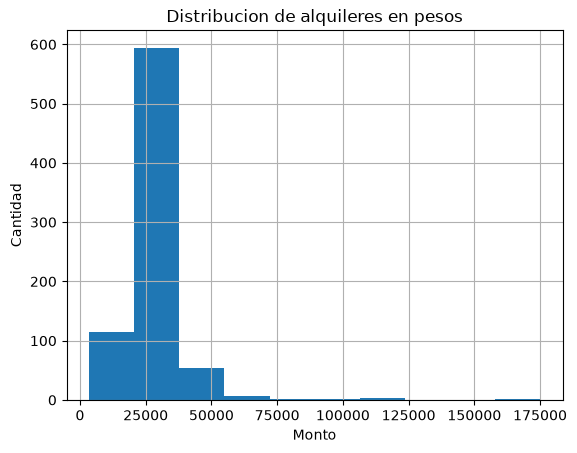

In [ ]:
if plt is None:
    print('matplotlib no esta instalado. Instalar con: pip install matplotlib')
else:
    df_pesos = df[df['moneda'] == '$'].copy()
    df_pesos['monto'].dropna().hist()
    plt.title('Distribucion de alquileres en pesos')
    plt.xlabel('Monto')
    plt.ylabel('Cantidad')
    plt.show()


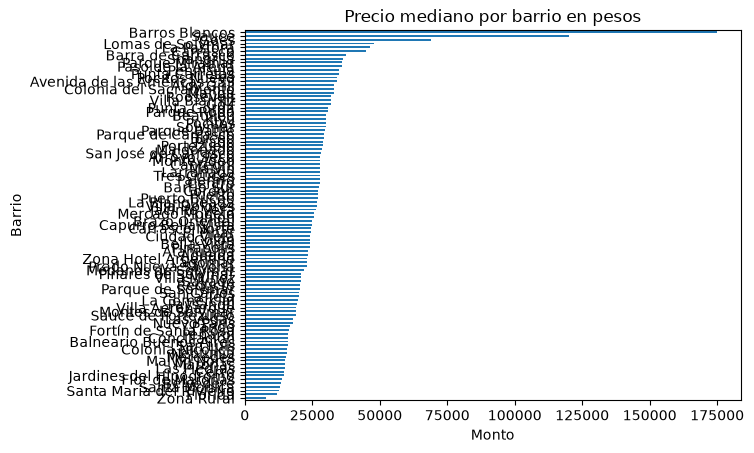

In [ ]:
if plt is not None:
    (
        df[df['moneda'] == '$']
        .groupby('barrio')['monto']
        .median()
        .sort_values()
        .plot(kind='barh')
    )
    plt.title('Precio mediano por barrio en pesos')
    plt.xlabel('Monto')
    plt.ylabel('Barrio')
    plt.show()


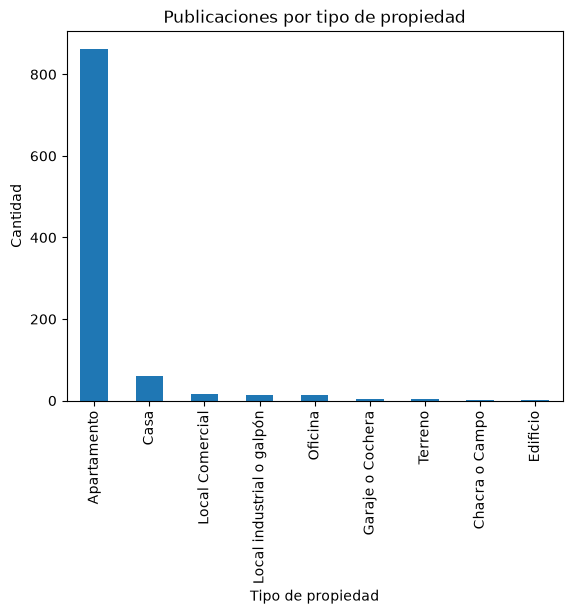

In [ ]:
if plt is not None:
    df['tipo_propiedad'].value_counts().plot(kind='bar')
    plt.title('Publicaciones por tipo de propiedad')
    plt.xlabel('Tipo de propiedad')
    plt.ylabel('Cantidad')
    plt.show()


## 15. Lectura inicial

Puntos a revisar antes de sacar conclusiones fuertes:

- La muestra actual es chica y viene de una busqueda especifica.
- Hay que separar precios por moneda o convertirlos a una moneda comun.
- `tipo_propiedad` permite comparar segmentos, pero algunos tipos pueden tener pocos casos.
- `referencia` sirve para deduplicar cuando se amplie el scraping.
- `metros_cuadrados` puede requerir revision manual si la publicacion informa varias superficies.
- El ranking de oportunidades usa tipo de cambio fijo de 40 pesos por dolar y debe revisarse si cambia el mercado.
- Gastos comunes no informados se penalizan porque pueden esconder costo mensual real.
